In [105]:
import os

base_path = "/kaggle/input/datasets/srinivasac/flickr30k-dataset/flickr30k/"

for root, dirs, files in os.walk(base_path):
    print(root)
    break

/kaggle/input/datasets/srinivasac/flickr30k-dataset/flickr30k/


In [106]:
import os
import shutil

files_to_delete = [
    "features.pkl",
    "features_train.pkl",
    "features_val.pkl",
    "features_partial.pkl",
    "features_val_partial.pkl",
    "tokenizer.pkl",
    "config.json",
    "caption_model.keras",
    "best_model.keras",
    "training_loss.png",
    "training_accuracy.png",
    "caption.mp3"
    'model_initial.keras'
]

for file in files_to_delete:
    if os.path.exists(file):
        os.remove(file)
        print(f"Deleted: {file}")

# Optional: clear working directory leftovers
for root, dirs, files in os.walk(".", topdown=False):
    for name in files:
        if name.endswith((".pkl", ".mp3", ".png", ".keras")):
            try:
                os.remove(os.path.join(root, name))
            except:
                pass

In [107]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/srinivasac/flickr30k-dataset/flickr30k/captions.txt')
df.head()

,image,caption
0,1000092795.jpg,Two young guys with shaggy hair look at their...
1,1000092795.jpg,"Two young , White males are outside near many..."
2,1000092795.jpg,Two men in green shirts are standing in a yard .
3,1000092795.jpg,A man in a blue shirt standing in a garden .
4,1000092795.jpg,Two friends enjoy time spent together .


In [108]:
print("Total rows:", len(df))
print("Unique images:", df['image'].nunique())
df.head(10)

Total rows: 158915
Unique images: 31783


,image,caption
0,1000092795.jpg,Two young guys with shaggy hair look at their...
1,1000092795.jpg,"Two young , White males are outside near many..."
2,1000092795.jpg,Two men in green shirts are standing in a yard .
3,1000092795.jpg,A man in a blue shirt standing in a garden .
4,1000092795.jpg,Two friends enjoy time spent together .
5,10002456.jpg,Several men in hard hats are operating a gian...
6,10002456.jpg,Workers look down from up above on a piece of...
7,10002456.jpg,Two men working on a machine wearing hard hats .
8,10002456.jpg,Four men on top of a tall structure .
9,10002456.jpg,Three men on a large rig .


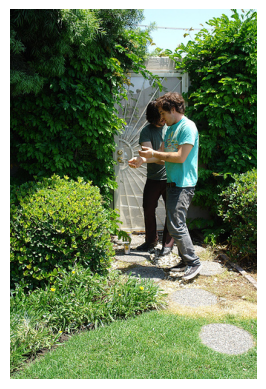

In [109]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/kaggle/input/datasets/srinivasac/flickr30k-dataset/flickr30k/Images/" + df['image'][0]

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

step 2


In [110]:
df.head(5)

,image,caption
0,1000092795.jpg,Two young guys with shaggy hair look at their...
1,1000092795.jpg,"Two young , White males are outside near many..."
2,1000092795.jpg,Two men in green shirts are standing in a yard .
3,1000092795.jpg,A man in a blue shirt standing in a garden .
4,1000092795.jpg,Two friends enjoy time spent together .


In [111]:
df = df.dropna(subset=['caption'])

In [112]:
df['caption'] = df['caption'].astype(str)

In [113]:
import re

def clean_caption(caption):
    if not isinstance(caption, str):
        return ""
    caption = caption.lower()
    caption = re.sub(r'[^a-z ]', '', caption)
    caption = re.sub(r'\s+', ' ', caption)
    caption = caption.strip()
    return caption

df['cleaned'] = df['caption'].apply(clean_caption)

In [114]:
df['cleaned'] = df['cleaned'].apply(
    lambda x: 'startseq ' + x + ' endseq'
)

In [115]:
df[['caption', 'cleaned']].head(5)

,caption,cleaned
0,Two young guys with shaggy hair look at their...,startseq two young guys with shaggy hair look ...
1,"Two young , White males are outside near many...",startseq two young white males are outside nea...
2,Two men in green shirts are standing in a yard .,startseq two men in green shirts are standing ...
3,A man in a blue shirt standing in a garden .,startseq a man in a blue shirt standing in a g...
4,Two friends enjoy time spent together .,startseq two friends enjoy time spent together...


In [116]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['cleaned'])

In [117]:
vocab_size = len(tokenizer.word_index) + 1
print("Vocab size:", vocab_size)

Vocab size: 19773


In [118]:
max_length = max(len(c.split()) for c in df['cleaned'])
print("Max length:", max_length)

Max length: 80


In [119]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

step 3

In [120]:
images = df['image'].unique()
print("Total unique images:", len(images))

Total unique images: 31783


In [121]:
import random
random.seed(42)   # for reproducibility
random.shuffle(images)

In [122]:
train_size = int(len(images) * 0.8)
val_size = int(len(images) * 0.1)

train_images = images[:train_size]
val_images = images[train_size:train_size + val_size]
test_images = images[train_size + val_size:]

In [123]:
train_df = df[df['image'].isin(train_images)]
val_df = df[df['image'].isin(val_images)]
test_df = df[df['image'].isin(test_images)]

In [124]:
print("Train images:", train_df['image'].nunique())
print("Val images:", val_df['image'].nunique())
print("Test images:", test_df['image'].nunique())

Train images: 25426
Val images: 3178
Test images: 3179


In [125]:
print(set(train_images) & set(val_images))
print(set(train_images) & set(test_images))
print(set(val_images) & set(test_images))

set()
set()
set()


In [126]:
import pickle

with open("train_images.pkl", "wb") as f:
    pickle.dump(train_images, f)

with open("val_images.pkl", "wb") as f:
    pickle.dump(val_images, f)

with open("test_images.pkl", "wb") as f:
    pickle.dump(test_images, f)

step 4

In [127]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model

base_model = EfficientNetB0(weights='imagenet', include_top=False)

model_cnn = Model(
    inputs=base_model.input,
    outputs=base_model.output   # shape: (7, 7, 1280)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [128]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np

In [129]:
def extract_features(img_path):
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img = keras_image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    feature = model_cnn.predict(img, verbose=0)
    
    # reshape to (49, 1280)
    feature = np.reshape(feature, (feature.shape[0], -1, feature.shape[-1]))
    
    return feature

In [130]:
import os
from tqdm import tqdm  # progress bar

features = {}
img_dir = "/kaggle/input/datasets/srinivasac/flickr30k-dataset/flickr30k/Images/"

for img in tqdm(train_images):
    path = os.path.join(img_dir, img)
    
    # check if file exists
    if not os.path.exists(path):
        print(f"Missing: {path}")
        continue
    
    feature = extract_features(path)
    features[img] = feature

100%|██████████| 25426/25426 [46:26<00:00,  9.12it/s]  


In [131]:
import pickle

with open("features_train.pkl", "wb") as f:
    pickle.dump(features, f)

In [132]:
print(len(features))
print(features[list(features.keys())[0]].shape)

25426
(1, 49, 1280)


In [133]:
from tqdm import tqdm
import pickle
import os

features_val = {}

for i, img in enumerate(tqdm(val_images, desc="Extracting VAL features")):
    path = os.path.join(img_dir, img)
    
    if not os.path.exists(path):
        continue
    
    features_val[img] = extract_features(path)
    
    # save every 500 images
    if i % 500 == 0:
        with open("features_val_partial.pkl", "wb") as f:
            pickle.dump(features_val, f)

# final save
with open("features_val.pkl", "wb") as f:
    pickle.dump(features_val, f)

Extracting VAL features: 100%|██████████| 3178/3178 [06:05<00:00,  8.70it/s]


step 5

In [134]:
from collections import defaultdict

image_captions = defaultdict(list)

for _, row in train_df.iterrows():
    image_captions[row['image']].append(row['cleaned'])

In [135]:
list(image_captions.items())[:1]

[('1000092795.jpg',
  ['startseq two young guys with shaggy hair look at their hands while hanging out in the yard endseq',
   'startseq two young white males are outside near many bushes endseq',
   'startseq two men in green shirts are standing in a yard endseq',
   'startseq a man in a blue shirt standing in a garden endseq',
   'startseq two friends enjoy time spent together endseq'])]

In [136]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

In [137]:
def data_generator(image_captions, features, tokenizer, max_length, vocab_size, batch_size=32):
    
    X1, X2, y = [], [], []
    
    while True:
        for img, captions in image_captions.items():
            
            feature = features[img][0]   # shape (1280,)
            
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                
                for i in range(1, len(seq)):
                    in_seq = seq[:i]
                    out_seq = seq[i]
                    
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)
                    
                    if len(X1) == batch_size:
                        yield ((np.array(X1), np.array(X2)), np.array(y))
                        X1, X2, y = [], [], []

In [138]:
gen = data_generator(image_captions, features, tokenizer, max_length, vocab_size)

X, y = next(gen)

print(X[0].shape)  # image features
print(X[1].shape)  # sequences
print(y.shape)     # output

(32, 49, 1280)
(32, 80)
(32, 19773)


step 6

In [139]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout
from tensorflow.keras.layers import AdditiveAttention, TimeDistributed, RepeatVector
from tensorflow.keras.models import Model

In [140]:
inputs1 = Input(shape=(49, 1280))   # attention features

fe1 = Dropout(0.5)(inputs1)
fe2 = TimeDistributed(Dense(256, activation='relu'))(fe1)

In [141]:
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = LSTM(256, return_sequences=True)(se1)

In [142]:
attention = AdditiveAttention()([se2, fe2])

In [143]:
decoder1 = Dense(256, activation='relu')(attention)
decoder2 = LSTM(256)(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

In [162]:
model = Model(inputs=[inputs1, inputs2], outputs=outputs)

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)  # default is 0.001

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [163]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 49, 1280)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 80, 256)   │  5,061,888 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 80)        │          0 │ input_layer_7[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 49, 1280)  │          0 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 80, 256)   │    525,312 │ embedding_2[0][0… │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 49, 256)   │    327,936 │ dropout_4[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additive_attention  │ (None, 80, 256)   │        256 │ lstm_2[0][0],     │
│ (AdditiveAttention) │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 80, 256)   │     65,792 │ additive_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convert_to_tensor   │ (None, 80)        │          0 │ not_equal_2[0][0] │
│ (ConvertToTensor)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 256)       │    525,312 │ dense_7[0][0],    │
│                     │                   │            │ convert_to_tenso… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 19773)     │  5,081,661 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,588,157 (44.21 MB)

 Trainable params: 11,588,157 (44.21 MB)

 Non-trainable params: 0 (0.00 B)

In [165]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [166]:
# Early stopping (stop if no improvement)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

# Save best model
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Reduce learning rate when stuck
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

In [167]:
model.save("model_initial.keras")

step 7

In [168]:
train_generator = data_generator(
    image_captions, 
    features, 
    tokenizer, 
    max_length, 
    vocab_size
)

val_image_captions = {}

from collections import defaultdict
val_image_captions = defaultdict(list)

for _, row in val_df.iterrows():
    val_image_captions[row['image']].append(row['cleaned'])

val_generator = data_generator(
    val_image_captions,
    features_val,
    tokenizer,
    max_length,
    vocab_size
)

In [169]:
train_steps = len(train_df) // 32
val_steps = len(val_df) // 32

print(train_steps, val_steps)

3972 496


In [170]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=30,
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=[early_stop, checkpoint, lr_scheduler]
)

Epoch 1/30
3971/3972 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3011 - loss: 4.0482
Epoch 1: val_loss improved from inf to 4.13672, saving model to best_model.keras
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 156s 38ms/step - accuracy: 0.3011 - loss: 4.0482 - val_accuracy: 0.3069 - val_loss: 4.1367 - learning_rate: 1.0000e-04
Epoch 2/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3020 - loss: 3.9788
Epoch 2: val_loss did not improve from 4.13672
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 153s 39ms/step - accuracy: 0.3020 - loss: 3.9788 - val_accuracy: 0.2913 - val_loss: 4.1936 - learning_rate: 1.0000e-04
Epoch 3/30
3971/3972 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3137 - loss: 3.8518
Epoch 3: val_loss improved from 4.13672 to 3.92518, saving model to best_model.keras
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 156s 39ms/step - accuracy: 0.3137 - loss: 3.8518 - val_accuracy: 0.3159 - val_loss: 3.9252 - learning_rate: 1.0000e-04
Epoch 4/30
3971/3972 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3

step 8

In [171]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def beam_search(model, tokenizer, photo, max_length, beam_width=7):
    
    start = [tokenizer.word_index['startseq']]
    
    sequences = [[start, 0.0]]  # (sequence, score)
    
    for _ in range(max_length):
        all_candidates = []
        
        for seq, score in sequences:
            
            padded = pad_sequences([seq], maxlen=max_length, padding='post')
            preds = model.predict([photo, padded], verbose=0)[0]
            
            # top-k words
            top_k = np.argsort(preds)[-beam_width:]
            
            for word in top_k:
                candidate = seq + [word]
                candidate_score = score - np.log(preds[word] + 1e-10)
                all_candidates.append([candidate, candidate_score])
        
        # sort and select best k
        ordered = sorted(all_candidates, key=lambda x: x[1])
        sequences = ordered[:beam_width]
    
    # best sequence
    best_seq = sequences[0][0]
    
    # convert to words
    caption = []
    for idx in best_seq:
        word = tokenizer.index_word.get(idx)
        if word is None:
            continue
        if word == 'endseq':
            break
        caption.append(word)
    
    return ' '.join(caption[1:])  # remove startseq

In [172]:
img = list(test_images)[1]
img_path = os.path.join(img_dir, img)

photo = extract_features(img_path)

caption = beam_search(
    model, 
    tokenizer, 
    photo, 
    max_length, 
    beam_width=7  # 🔥 increase for better results
)

print("Caption:", caption)

Caption: a group of people are walking on a road


In [174]:
from PIL import Image
import matplotlib.pyplot as plt
import os

def show_image_with_caption(img_path, caption):
    img = Image.open(img_path)
    
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(caption, fontsize=12)
    plt.axis('off')
    plt.show()

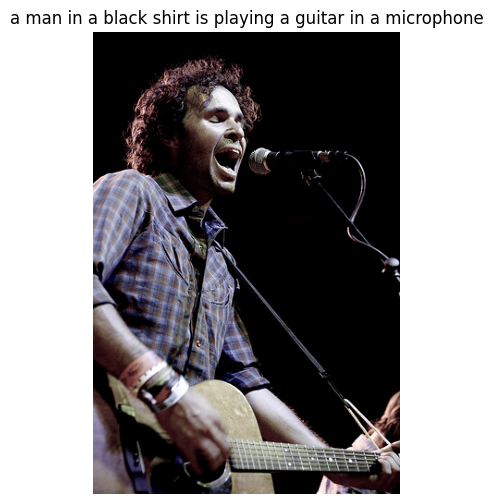

In [176]:
img = list(test_images)[10]
img_path = os.path.join(img_dir, img)

photo = extract_features(img_path)

caption = beam_search(
    model,
    tokenizer,
    photo,
    max_length,
    beam_width=5
)

show_image_with_caption(img_path, caption)

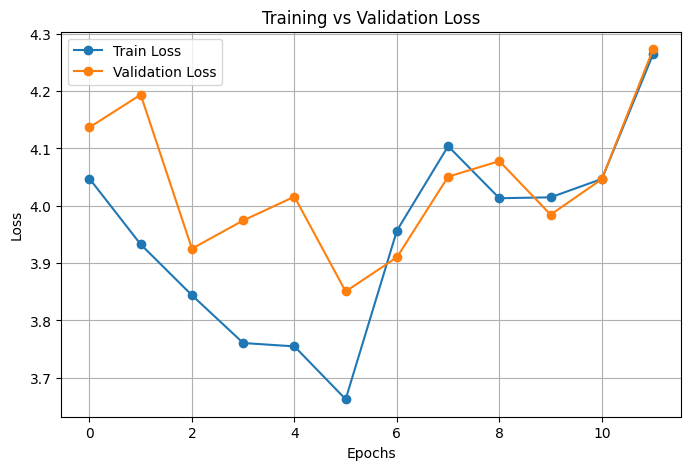

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.grid()

plt.savefig("loss_graph.png", dpi=300, bbox_inches='tight')
plt.show()

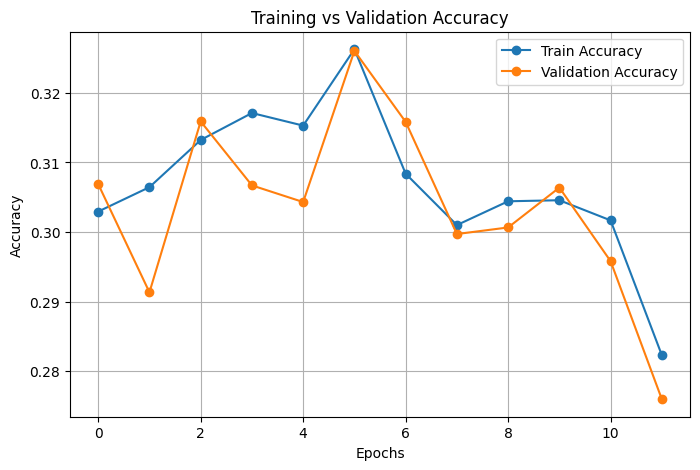

In [178]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.grid()

plt.savefig("accuracy_graph.png", dpi=300, bbox_inches='tight')
plt.show()

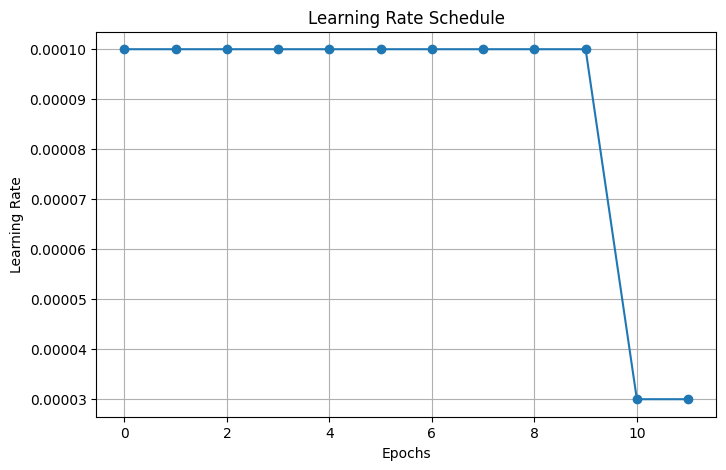

In [179]:
# if using ReduceLROnPlateau
lr = history.history.get('lr') or history.history.get('learning_rate')

if lr:
    plt.figure(figsize=(8,5))
    plt.plot(lr, marker='o')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.grid()
    
    plt.savefig("lr_graph.png", dpi=300, bbox_inches='tight')
    plt.show()

In [182]:
!pip install gtts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [186]:
from gtts import gTTS
from IPython.display import Audio

def caption_to_audio(caption, filename="caption.mp3"):
    
    # clean caption (remove tokens if present)
    caption = caption.replace("startseq", "").replace("endseq", "").strip()
    
    # convert to speech
    tts = gTTS(text=caption, lang='en')
    tts.save(filename)
    
    print("Caption:", caption)
    
    return Audio(filename)

In [184]:
audio = caption_to_audio(caption)

Caption: a man in a black shirt is playing a guitar in a microphone


In [188]:
def full_demo(model, tokenizer, img_path, max_length):
    
    photo = extract_features(img_path)
    
    caption = beam_search(model, tokenizer, photo, max_length, beam_width=5)
    caption = caption.replace("startseq", "").replace("endseq", "").strip()
    
    # show image
    from PIL import Image
    import matplotlib.pyplot as plt
    
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(caption)
    plt.axis('off')
    plt.show()
    
    # audio
    return caption_to_audio(caption)

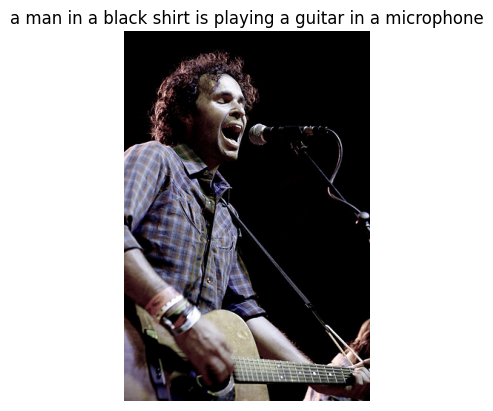

Caption: a man in a black shirt is playing a guitar in a microphone


In [192]:
img = list(test_images)[10]
img_path = os.path.join(img_dir, img)

full_demo(model, tokenizer, img_path, max_length)

In [190]:
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.2 which is incompatible.


In [193]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_blip = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

device = "cuda" if torch.cuda.is_available() else "cpu"
model_blip.to(device)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [194]:
def blip_caption(img_path):
    image = Image.open(img_path).convert('RGB')
    
    inputs = processor(images=image, return_tensors="pt").to(device)
    
    output = model_blip.generate(**inputs)
    
    caption = processor.decode(output[0], skip_special_tokens=True)
    
    return caption

In [214]:
img = list(test_images)[10]
img_path = os.path.join(img_dir, img)

caption = blip_caption(img_path)
print("BLIP Caption:", caption)

BLIP Caption: a man playing a guitar


In [215]:
caption_to_audio(caption)

Caption: a man playing a guitar


In [197]:
!pip install nltk

In [198]:
from nltk.translate.bleu_score import corpus_bleu

In [199]:
references = []
predictions_model = []
predictions_blip = []

In [202]:
for img in list(test_images)[:100]:   # use 100 for speed
    
    # ground truth captions
    actual_captions = test_df[test_df['image'] == img]['cleaned'].tolist()
    
    # remove tokens + split
    actual_captions = [c.replace("startseq", "").replace("endseq", "").split() 
                       for c in actual_captions]
    
    # --- Your Model ---
    photo = extract_features(os.path.join(img_dir, img))
    pred1 = beam_search(model, tokenizer, photo, max_length, beam_width=3)
    pred1 = pred1.split()
    
    # --- BLIP ---
    pred2 = blip_caption(os.path.join(img_dir, img)).split()
    
    references.append(actual_captions)
    predictions_model.append(pred1)
    predictions_blip.append(pred2)

In [203]:
# BLEU-1
bleu1_model = corpus_bleu(references, predictions_model, weights=(1,0,0,0))
bleu1_blip = corpus_bleu(references, predictions_blip, weights=(1,0,0,0))

# BLEU-4 (standard)
bleu4_model = corpus_bleu(references, predictions_model)
bleu4_blip = corpus_bleu(references, predictions_blip)

print("Your Model BLEU-1:", bleu1_model)
print("BLIP BLEU-1:", bleu1_blip)

print("Your Model BLEU-4:", bleu4_model)
print("BLIP BLEU-4:", bleu4_blip)

Your Model BLEU-1: 0.507147296457427
BLIP BLEU-1: 0.6048048696554944
Your Model BLEU-4: 0.12924818678239602
BLIP BLEU-4: 0.2668414772765722


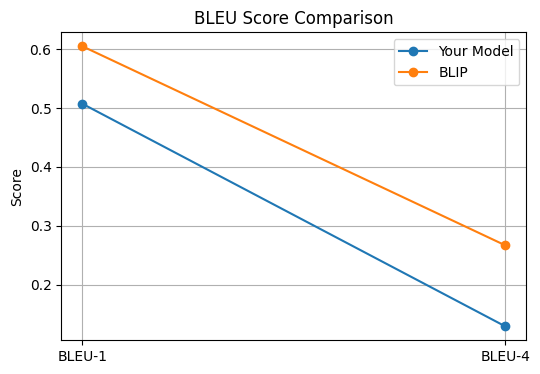

In [204]:
import matplotlib.pyplot as plt

labels = ['BLEU-1', 'BLEU-4']
model_scores = [bleu1_model, bleu4_model]
blip_scores = [bleu1_blip, bleu4_blip]

x = range(len(labels))

plt.figure(figsize=(6,4))
plt.plot(x, model_scores, marker='o')
plt.plot(x, blip_scores, marker='o')

plt.xticks(x, labels)
plt.title("BLEU Score Comparison")
plt.ylabel("Score")
plt.legend(["Your Model", "BLIP"])
plt.grid()

plt.savefig("bleu_comparison.png", dpi=300)
plt.show()

In [205]:
import json

config = {
    "max_length": max_length,
    "vocab_size": vocab_size
}

with open("config.json", "w") as f:
    json.dump(config, f)

print("Saved config.json")

Saved config.json


In [206]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Saved tokenizer.pkl")

Saved tokenizer.pkl


In [207]:
model.save("best_model.keras")
print("Saved best_model.keras")

Saved best_model.keras


In [208]:
beam_code = """
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def beam_search(model, tokenizer, photo, max_length, beam_width=5):
    start = [tokenizer.word_index['startseq']]
    sequences = [[start, 0.0]]

    for _ in range(max_length):
        all_candidates = []
        for seq, score in sequences:
            padded = pad_sequences([seq], maxlen=max_length, padding='post')
            preds = model.predict([photo, padded], verbose=0)[0]

            top_k = np.argsort(preds)[-beam_width:]

            for word in top_k:
                candidate = seq + [word]
                candidate_score = score - np.log(preds[word] + 1e-10)
                all_candidates.append([candidate, candidate_score])

        ordered = sorted(all_candidates, key=lambda x: x[1])
        sequences = ordered[:beam_width]

    best_seq = sequences[0][0]

    caption = []
    for idx in best_seq:
        word = tokenizer.index_word.get(idx)
        if word is None:
            continue
        if word == 'endseq':
            break
        caption.append(word)

    return ' '.join(caption[1:])
"""

with open("beam_search.py", "w") as f:
    f.write(beam_code)

print("Saved beam_search.py")

Saved beam_search.py


In [209]:
import pickle

with open("history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Saved history.pkl")

Saved history.pkl


In [210]:
results = []

for img in list(test_images)[:20]:
    img_path = os.path.join(img_dir, img)
    photo = extract_features(img_path)
    
    caption = beam_search(model, tokenizer, photo, max_length, beam_width=5)
    
    results.append((img, caption))

with open("sample_results.txt", "w") as f:
    for img, cap in results:
        f.write(f"{img} : {cap}\n")

print("Saved sample_results.txt")

Saved sample_results.txt


In [211]:
bleu_data = {
    "bleu1_model": bleu1_model,
    "bleu4_model": bleu4_model,
    "bleu1_blip": bleu1_blip,
    "bleu4_blip": bleu4_blip
}

import json
with open("bleu_scores.json", "w") as f:
    json.dump(bleu_data, f)

print("Saved bleu_scores.json")

Saved bleu_scores.json


In [212]:
plt.savefig("loss_graph.png", dpi=300)
plt.savefig("accuracy_graph.png", dpi=300)
plt.savefig("lr_graph.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [213]:
import zipfile
import os

files = [
    "best_model.keras",
    "tokenizer.pkl",
    "config.json",
    "beam_search.py",
    "history.pkl",
    "sample_results.txt",
    "bleu_scores.json",
    "loss_graph.png",
    "accuracy_graph.png"
]

with zipfile.ZipFile("FINAL_PROJECT.zip", "w") as zipf:
    for file in files:
        if os.path.exists(file):
            zipf.write(file)

print("✅ FINAL_PROJECT.zip ready for download")

✅ FINAL_PROJECT.zip ready for download
